# dust_viz worksheet


In [1]:
%load_ext autoreload 
#hopefully this will reload the modules when they are changed specifically when i change the plotting modules
%autoreload 2

In [2]:
import iapi_TNG as iapi
import h5py
import numpy as np

#construct url for halo cutout
#Replace [HALO_ID] with the index into the FoF catalog for the halo of interest
# halo_cutout_url = 'http://www.tng-project.org/api/TNG300-1/snapshots/99/halos/[HALO_ID]/cutout.hdf5' 
haloNum = 0  # Change this to the halo number you want to download
halo_cutout_url = f'http://www.tng-project.org/api/TNG300-1/snapshots/99/halos/{haloNum}/cutout.hdf5'

# Build the request for the parameters of interest, these are the ones that are in the particle files I have
# We probably won't use all of them, so for quicker testing you can just grab the most important ones: 'Coordinates,Density,Masses,GFM_Metallicity,GFM_Metals,NeutralHydrogenAbundance,ElectronAbundance,StarFormationRate'
#Don't ask me why the request is formatted like this, it has something to do with the URL/HDF5 request and it will break if there are any spaces
params={'gas':'Coordinates,Density,ElectronAbundance,GFM_AGNRadiation,GFM_CoolingRate,GFM_Metallicity,GFM_Metals,GFM_MetalsTagged,InternalEnergy,MagneticField,Masses,NeutralHydrogenAbundance,ParticleIDs,StarFormationRate,Potential,SubfindHsml',}



#Download the cutout
#fName is the name the file will save to, get() automatically appends '.hdf5' extension
data_dir = '/Users/alexpoulin/Downloads/git/dust_viz/data/'  # Change this to your desired directory
fName = f'{data_dir}/halo_{haloNum}'

#check if the hdf5 was downloaded already
#check fname.hdf5 exists
import os
skip = False  # Flag to skip downloading if the file is valid
if os.path.exists(fName+'.hdf5'):
    print(f"File {fName}.hdf5 already exists. Checking if it is not corrupted.")
    #try to open the file, if it fails, download it again
    try:
        with h5py.File(fName+'.hdf5', 'r') as f:
            print("File is valid and not corrupted.")
            skip = True  # Set skip to True if the file is valid
    except OSError:
        print("File is corrupted. Downloading again.")
else:
    #if it doesn't exist, download it
    print(f"Downloading cutout to {fName}.hdf5")
    
if not skip:    
    cutout = iapi.get(halo_cutout_url, params = params, fName = fName)
    #To read the files
with h5py.File(fName+'.hdf5', 'r') as f:
    #Load a parameter from the file, use [:] to make the hdf5 dataset act like a normal array (not totally sure why tbh)
    coordinates = f['PartType0']['Coordinates'][:] #'PartType0' means gas particles
    #or use np.asarray
    # masses = np.asarray(f['PartType0']['Masses'])
    print(f['PartType0']['SubfindHsml'][:]) 
    
    #print all the keys for PartType0
    print(f['PartType0'].keys())
# else:


# #save group catalog
# if os.
# group_url = f"http://www.tng-project.org/api/TNG300-1/snapshots/99/halos/{haloNum}/"
# group_data = iapi.get(group_url)


    
    

File /Users/alexpoulin/Downloads/git/dust_viz/data//halo_0.hdf5 already exists. Checking if it is not corrupted.
File is valid and not corrupted.
[ 2.300784   2.5426607  2.7991643 ... 34.172882  11.595225  14.486632 ]
<KeysViewHDF5 ['Coordinates', 'Density', 'ElectronAbundance', 'GFM_AGNRadiation', 'GFM_CoolingRate', 'GFM_Metallicity', 'GFM_Metals', 'GFM_MetalsTagged', 'InternalEnergy', 'MagneticField', 'Masses', 'NeutralHydrogenAbundance', 'ParticleIDs', 'Potential', 'StarFormationRate', 'SubfindHsml']>


In [3]:
with h5py.File(fName+'.hdf5', 'r') as f:
    print(f.keys())

<KeysViewHDF5 ['Header', 'PartType0']>


In [4]:
print('Coordinates shape:', coordinates.shape)
print(coordinates[0])

Coordinates shape: (31423633, 3)
[ 43711.32625977  48811.97000746 147607.34346898]


# svae group data

In [5]:
sim = 'TNG300-1'
snap = 99
data_dir = '/Users/alexpoulin/Downloads/git/dust_viz/data/'
groupcat_url = f'http://www.tng-project.org/api/{sim}/files/groupcat-{snap}/'
groupcat_fname = f'{data_dir}groupcat_{snap}.hdf5'

# Download the group catalog if not already present
import os
if not os.path.exists(groupcat_fname):
    print(f"Downloading group catalog to {groupcat_fname}")
    iapi.get(groupcat_url, fName=groupcat_fname)
else:
    print(f"Group catalog already exists at {groupcat_fname}")
    
    
import h5py
with h5py.File(groupcat_fname, 'r') as f:
    print(f.keys())  # Should show 'Group', 'Header', etc.
    group_r200 = f['Group']['Group_R_Crit200'][:]

FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = '/Users/alexpoulin/Downloads/git/dust_viz/data/groupcat_99.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from scipy.stats import gaussian_kde
import matplotlib.gridspec as gridspec
from scipy.interpolate import griddata

In [15]:
#grab 1000 random points in coordinates with seed 0
np.random.seed(0)
#this is the random seed, so you can get the same points every time
random_indices = np.random.choice(coordinates.shape[0], 10000, replace=False)
random_num_coordinates = coordinates[random_indices]
#save as a numpy array
np.save(f'{data_dir}pointdata/random_10000_coordinates.npy', random_num_coordinates)
np.save(f'{data_dir}pointdata/random_10000_coordinates.txt', random_num_coordinates)
#save as a .xyz file
with open(f'{data_dir}pointdata/random_10000_coordinates.xyz', 'w') as f:
    for coord in random_num_coordinates:
        f.write(f"{coord[0]} {coord[1]} {coord[2]}\n")

In [16]:
# Function to create density plot with appropriate opacity
def create_density_plot(x_data, y_data, z_data, thresholds, ax):
    # Calculate point density
    xy = np.vstack([x_data, y_data])
    density = gaussian_kde(xy)(xy)
    
    # Normalize density for colormapping
    norm = Normalize(vmin=min(density), vmax=max(density))
    
    # Create scatter plots for each iso-contour with different opacity
    for i in range(len(thresholds)-1):
        mask = (z_data >= thresholds[i]) & (z_data < thresholds[i+1])
        if i == len(thresholds)-2:
            # Innermost contour - fully opaque
            alpha = 1.0
        else:
            # Outer contours - 80% transparent as per paper
            alpha = 0.2
        
        ax.scatter(x_data[mask], y_data[mask], 
                  c=density[mask], cmap='viridis', 
                  alpha=alpha, edgecolor='none')
    
    # Add gridlines
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Add markers for galaxies (if coordinates are known)
    # Example: ax.plot(galaxy_x, galaxy_y, 'go', markersize=10)

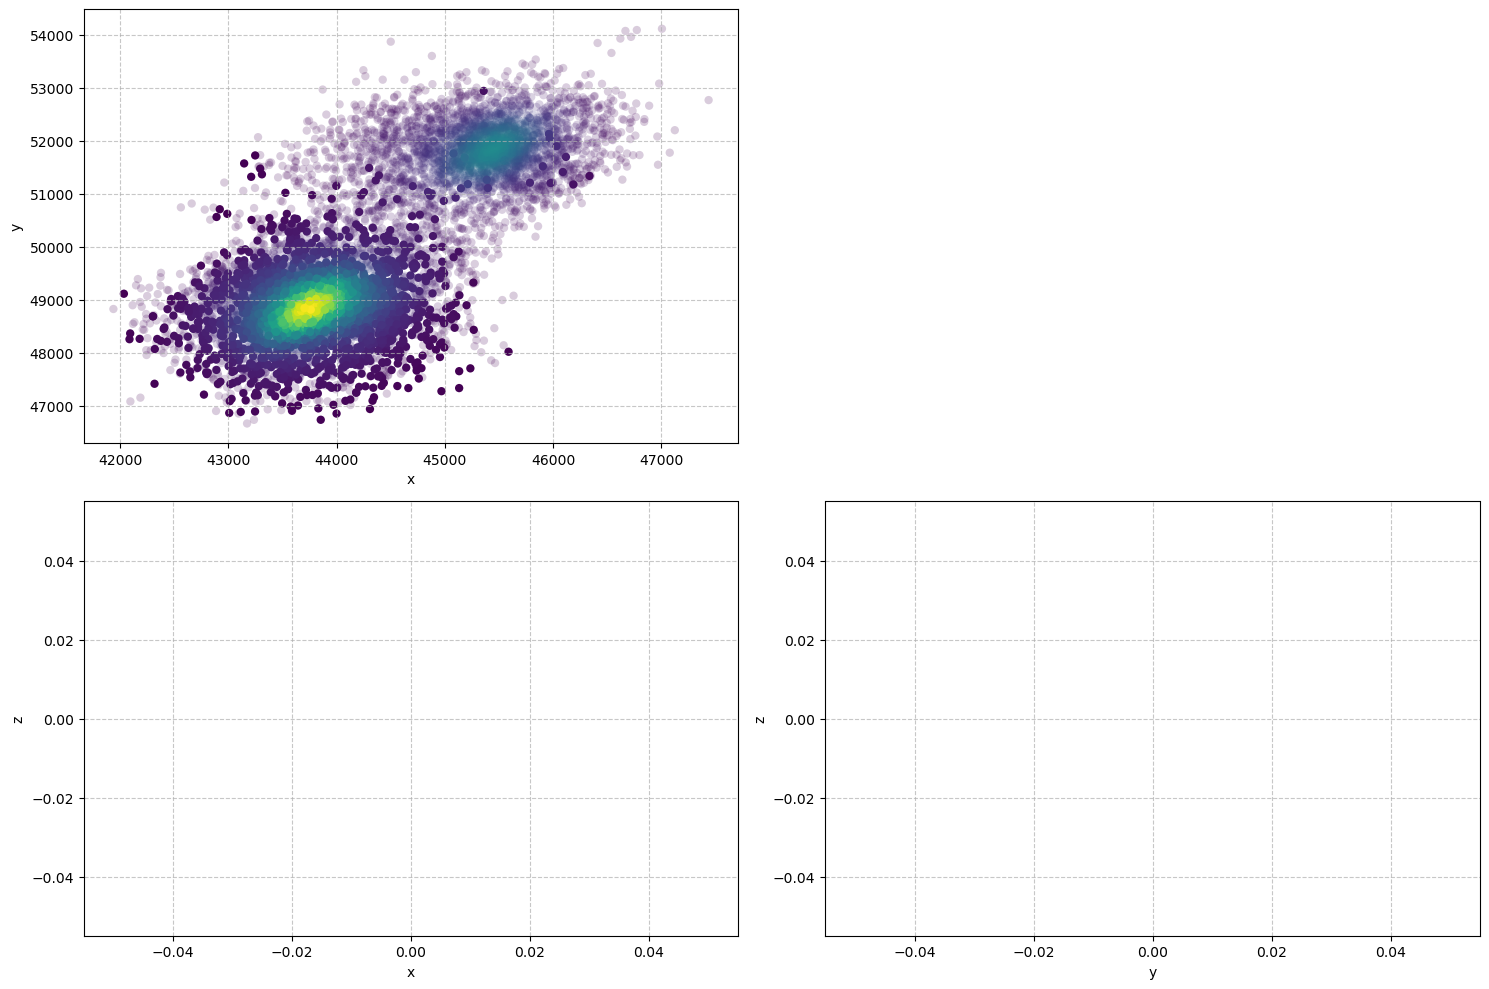

: 

In [ ]:


# Assuming your data is in a list of (x,y,z) tuples
# Convert to NumPy array for easier manipulation
data = np.array(random_num_coordinates)  # Replace with your actual data
x, y, z = data[:,0], data[:,1], data[:,2]

# Define z-value thresholds for iso-contours (adjust based on your data)
# The paper uses 1.3, 2.5, 3.5, and 6.0 mJy/beam
z_thresholds = [min(z), np.percentile(z, 25), np.percentile(z, 50), 
                np.percentile(z, 75), max(z)]

# Setup figure with grid for the three projections
fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])

# Top projection (x-y)
ax_top = plt.subplot(gs[0, 0])
create_density_plot(x, y, z, z_thresholds, ax_top)
ax_top.set_xlabel('x')
ax_top.set_ylabel('y')

# Front projection (x-z)
ax_front = plt.subplot(gs[1, 0])
create_density_plot(x, z, y, z_thresholds, ax_front)
ax_front.set_xlabel('x')
ax_front.set_ylabel('z')

# Side projection (z-y)
ax_side = plt.subplot(gs[1, 1])
create_density_plot(y, z, x, z_thresholds, ax_side)
ax_side.set_xlabel('y')
ax_side.set_ylabel('z')


#save the figure
plt.savefig('density_projections.png', dpi=300)
plt.tight_layout()
plt.show()

In [ ]:
from mayavi import mlab
import numpy as np

# Assuming your data is in a list of (x,y,z) tuples
data = np.array(random_num_coordinates)
x, y, z = data[:,0], data[:,1], data[:,2]

# Create a 3D density field from the point data
# This is a simplification - you may need more sophisticated binning
xi, yi, zi = np.mgrid[min(x):max(x):100j, min(y):max(y):100j, min(z):max(z):100j]
density = griddata((x, y, z), np.ones_like(x), (xi, yi, zi), method='linear', fill_value=0)

# Create figure
mlab.figure(bgcolor=(1, 1, 1), size=(800, 600))

# Create iso-contours with different opacity
# The paper uses 1.3, 2.5, 3.5, and 6.0 mJy/beam
contour_values = [np.percentile(density[density > 0], p) for p in [25, 50, 75, 90]]

# Create the contours with appropriate opacity
for i, value in enumerate(contour_values):
    if i == len(contour_values) - 1:
        # Innermost contour - fully opaque
        opacity = 1.0
    else:
        # Outer contours - 80% transparent as per paper
        opacity = 0.2
    
    mlab.contour3d(xi, yi, zi, density, contours=[value], opacity=opacity)

# Add markers for galaxies if you have their coordinates
# Example: mlab.points3d(galaxy_x, galaxy_y, galaxy_z, color=(0,1,0), scale_factor=10)

# Setup the view for top-front-side projections
# You'll need to save three different views

mlab.view(azimuth=0, elevation=90)  # Top view
mlab.savefig('top_view.png')

mlab.view(azimuth=0, elevation=0)   # Front view
mlab.savefig('front_view.png')

mlab.view(azimuth=90, elevation=0)  # Side view
mlab.savefig('side_view.png')

mlab.show()